<U+0001F4CC> OH: <U+7B2C>1<U+8EF8><U+306E><U+5BC4><U+4E0E><U+7387> = 21.51%
<U+0001F4CC> FP: <U+7B2C>1<U+8EF8><U+306E><U+5BC4><U+4E0E><U+7387> = 33.89%
<U+2705> <U+30B0><U+30E9><U+30D5><U+3092><U+8868><U+793A><U+30FB><U+4FDD><U+5B58><U+3057><U+307E><U+3057><U+305F>:
 - /Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/figs_compare/MDS_bar_top50_OH_vs_FP_20250822_1450.pdf
 - /Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/figs_compare/MDS_bar_top50_OH_vs_FP_20250822_1450.png


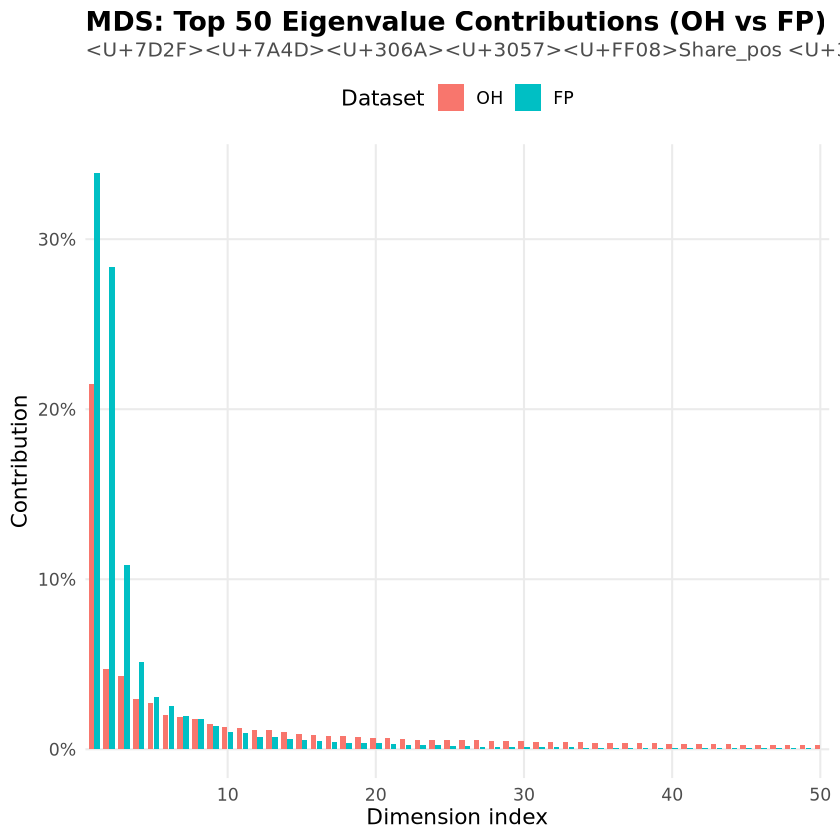

In [7]:
# ==== 実行ディレクトリ ====
# setwd(".../Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No")

# 必要パッケージ
if (!require(dplyr))     install.packages("dplyr");     library(dplyr)
if (!require(readr))     install.packages("readr");     library(readr)
if (!require(ggplot2))   install.packages("ggplot2");   library(ggplot2)
if (!require(scales))    install.packages("scales");    library(scales)

oh_csv <- "figs_OH/MDS_eigen_contributions_OH_20250821_1446.csv"
fp_csv <- "figs_FP/MDS_eigen_contributions_FP_20250821_1448.csv"

out_dir <- "figs_compare"
dir.create(out_dir, showWarnings = FALSE, recursive = TRUE)
timestamp <- format(Sys.time(), "%Y%m%d_%H%M")

# --- 読み込み関数（Dim, Share_pos を固定参照） ---
read_eigen_top50 <- function(path, label){
  df <- readr::read_csv(path, show_col_types = FALSE)
  if (!all(c("Dim","Share_pos") %in% names(df))) {
    stop(paste0("❌ 必要な列 (Dim, Share_pos) が見つかりません: ", path))
  }
  out <- df %>%
    transmute(
      Dataset = label,
      Dim = as.integer(Dim),
      Contribution = Share_pos
    ) %>%
    arrange(Dim) %>%
    slice_head(n = 50)
  if (nrow(out) >= 1) {
    cat(sprintf("📌 %s: 第1軸の寄与率 = %.2f%%\n", label, out$Contribution[1] * 100))
  }
  return(out)
}

oh <- read_eigen_top50(oh_csv, "OH")
fp <- read_eigen_top50(fp_csv, "FP")

all50 <- bind_rows(oh, fp) %>%
  mutate(Dataset = factor(Dataset, levels = c("OH","FP"))) %>%  # 順序を固定
  arrange(Dim, Dataset)
all50$Dim_f <- factor(all50$Dim, levels = sort(unique(all50$Dim)))

# --- 棒グラフ ---
p <- ggplot(all50, aes(x = Dim_f, y = Contribution, fill = Dataset)) +
  geom_col(position = position_dodge(width = 0.8), width = 0.75) +
  scale_y_continuous(labels = scales::percent_format(accuracy = 1)) +
  scale_x_discrete(breaks = as.character(seq(0, 50, by = 10))) +  # 10刻みで表示
  labs(
    title = "MDS: Top 50 Eigenvalue Contributions (OH vs FP)",
    subtitle = "累積なし（Share_pos を利用）",
    x = "Dimension index",
    y = "Contribution",
    fill = "Dataset"
  ) +
  theme_minimal(base_size = 13) +
  theme(
    panel.grid.minor = element_blank(),
    plot.title = element_text(face = "bold", size = 16, margin = margin(b = 4)),
    plot.subtitle = element_text(size = 12, color = "gray30"),
    legend.position = "top",
    axis.text.x = element_text(angle = 0, hjust = 0.5)  # 水平でOK
  )

print(p)

pdf_file <- file.path(out_dir, paste0("MDS_bar_top50_OH_vs_FP_", timestamp, ".pdf"))
png_file <- file.path(out_dir, paste0("MDS_bar_top50_OH_vs_FP_", timestamp, ".png"))
ggsave(pdf_file, p, width = 10, height = 6)
ggsave(png_file, p, width = 10, height = 6, dpi = 300)

cat("✅ グラフを表示・保存しました:\n - ",
    normalizePath(pdf_file), "\n - ",
    normalizePath(png_file), "\n", sep = "")


<U+0001F4C4> <U+4F7F><U+7528><U+30D5><U+30A1><U+30A4><U+30EB>:
 - OH: ./outputs_OH/MDScoords_nonlinear_cumeig_OH_20250821.csv 
 - FP: ./outputs_FP/MDScoords_nonlinear_cumeig_FP_20250821.csv 
<U+2705> <U+6563><U+5E03><U+56F3><U+3092><U+8868><U+793A><U+30FB><U+4FDD><U+5B58><U+3057><U+307E><U+3057><U+305F>:
 - /Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/figs_compare/MDS_scatter_Dim1xDim2_OH_FP_20250822_1515.pdf
 - /Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/figs_compare/MDS_scatter_Dim1xDim2_OH_FP_20250822_1515.png


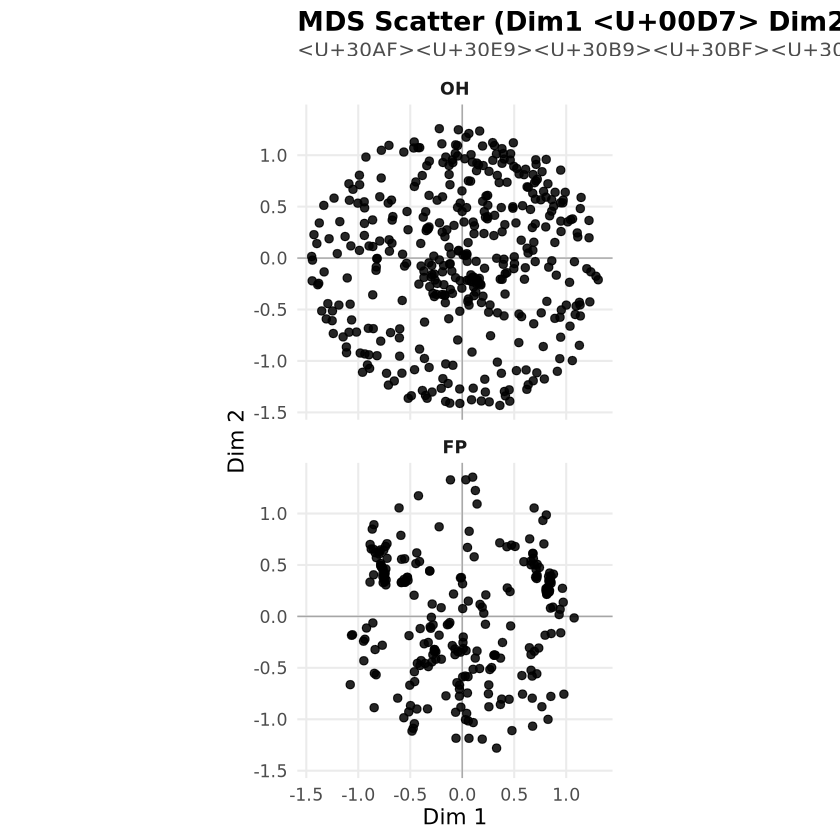

In [11]:
# ==== 実行ディレクトリ ====
# setwd(".../Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No")

# 必要パッケージ
if (!require(dplyr))     install.packages("dplyr");     library(dplyr)
if (!require(readr))     install.packages("readr");     library(readr)
if (!require(ggplot2))   install.packages("ggplot2");   library(ggplot2)
if (!require(stringr))   install.packages("stringr");   library(stringr)
if (!require(purrr))     install.packages("purrr");     library(purrr)

# 出力
out_dir <- "figs_compare"
dir.create(out_dir, showWarnings = FALSE, recursive = TRUE)
timestamp <- format(Sys.time(), "%Y%m%d_%H%M")

# ---- ファイル自動検出（最新の座標CSVを拾う） ----
find_latest_coords <- function(dirpath, tag){
  # tag は "OH" または "FP"
  cand <- list.files(dirpath, pattern = paste0("^MDScoords_.*", tag, ".*\\.csv$"),
                     full.names = TRUE, recursive = TRUE)
  if (length(cand) == 0) return(NA_character_)
  cand[which.max(file.info(cand)$mtime)]
}

oh_file <- find_latest_coords(".", "OH")
fp_file <- find_latest_coords(".", "FP")

if (is.na(oh_file) || is.na(fp_file)) {
  stop(paste0(
    "❌ MDS 座標CSVが見つかりません。\n",
    "  - 探索条件: ファイル名に 'MDScoords_' と 'OH' / 'FP' を含む .csv\n",
    "  - 検索ディレクトリ: カレント以下（再帰）\n",
    "  - 例: MDScoords_linear_top3_OH_20250821.csv\n"
  ))
}

cat("📄 使用ファイル:\n - OH:", oh_file, "\n - FP:", fp_file, "\n")

# ---- 座標CSVの読み込み（行名=変数名を想定） ----
# write.csv(mds_points) デフォルト(row.names=TRUE)で保存された想定なので row.names=1 で読む
read_coords <- function(path, label){
  df <- read.csv(path, row.names = 1, check.names = FALSE)
  # 列名の候補（柔軟対応）：MDS1/MDS2 や X1/X2、"1"/"2" など
  nms <- names(df)
  # 候補の優先順
  c1 <- c("MDS1","Dim1","X1","1","Axis1","Dim_1")
  c2 <- c("MDS2","Dim2","X2","2","Axis2","Dim_2")
  pick <- function(cands) {
    hit <- cands[cands %in% nms]
    if (length(hit) >= 1) return(hit[1])
    # 数値列から順に取るfallback
    num_cols <- nms[sapply(df, is.numeric)]
    if (length(num_cols) >= 2) return(num_cols[1])
    stop(paste0("座標列が見つかりません: ", path))
  }
  xcol <- if (any(c1 %in% nms)) c1[c1 %in% nms][1] else pick(c1)
  ycol <- if (any(c2 %in% nms)) c2[c2 %in% nms][1] else {
    # xcol を除いた数値列の先頭を y に
    num_cols <- nms[sapply(df, is.numeric)]
    ycand <- setdiff(num_cols, xcol)
    if (length(ycand) == 0) stop(paste0("第2軸が見つかりません: ", path))
    ycand[1]
  }

  out <- df %>%
    dplyr::select(all_of(c(xcol, ycol))) %>%
    dplyr::mutate(Variable = rownames(.),
                  Dataset = label) %>%
    dplyr::rename(Dim1 = all_of(xcol), Dim2 = all_of(ycol)) %>%
    dplyr::select(Dataset, Variable, Dim1, Dim2)
  return(out)
}

oh <- read_coords(oh_file, "OH")
fp <- read_coords(fp_file, "FP")

all_vars <- dplyr::bind_rows(oh, fp) %>%
  dplyr::mutate(Dataset = factor(Dataset, levels = c("OH","FP")))  # 表示順固定

# ---- 作図（第1軸×第2軸、クラスター分類なし） ----
p <- ggplot(all_vars, aes(x = Dim1, y = Dim2)) +
  geom_hline(yintercept = 0, linewidth = 0.4, color = "grey65") +
  geom_vline(xintercept = 0, linewidth = 0.4, color = "grey65") +
  geom_point(alpha = 0.85, size = 2.0) +
  facet_wrap(~ Dataset, ncol = 1, scales = "fixed", strip.position = "top") +
  # coord_equal()  は削除
  labs(
    title = "MDS Scatter (Dim1 × Dim2): Variables",
    subtitle = "クラスター分類なし・各データセットの第1軸/第2軸でプロット",
    x = "Dim 1",
    y = "Dim 2"
  ) +
  theme_minimal(base_size = 13) +
  theme(
    aspect.ratio = 1,                   # ← 追加：各パネルを正方形に
    panel.grid.minor = element_blank(),
    plot.title = element_text(face = "bold", size = 16, margin = margin(b = 4)),
    plot.subtitle = element_text(size = 12, color = "gray30"),
    strip.text = element_text(face = "bold"),
    legend.position = "none"
  )


# コンソール表示
print(p)

# 保存
pdf_file <- file.path(out_dir, paste0("MDS_scatter_Dim1xDim2_OH_FP_", timestamp, ".pdf"))
png_file <- file.path(out_dir, paste0("MDS_scatter_Dim1xDim2_OH_FP_", timestamp, ".png"))
ggsave(pdf_file, p, width = 8, height = 9)      # 縦長（上下2面）
ggsave(png_file, p, width = 8, height = 9, dpi = 300)

cat("✅ 散布図を表示・保存しました:\n - ",
    normalizePath(pdf_file), "\n - ",
    normalizePath(png_file), "\n", sep = "")
